In [306]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [307]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'n_cs_vs_K_parameter_swipe'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251216-120719'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [308]:
final_abundance_data = data['all_N_final']
final_resource_data = data['all_R_final']


In [309]:
final_abundance_matrix = np.zeros((args.N_cs, args.N_K_std, args.N_Csp, args.iterations, 4))
all_C = {}
counter = 0
for i in range(args.N_cs):
    for j in range(args.N_K_std):
        for k in range(args.N_Csp):
            final_abundance_matrix[i,j,k,:,:] = final_abundance_data[counter]
            counter += 1
            # for l in range(args.iterations):
            #     key = (i, j, k, l)
            #     all_C[key] = data[f'C_{counter}_{l}'] 

In [310]:
if False:
    all_C = {}
    all_D = {}
    for x, d in data.items():
        if 'C_' in x:
            all_C[x] = d
        if 'D_' in x:
            all_D[x] = d

In [311]:
data['all_N_final'].shape

(528, 50, 4)

In [312]:
richness_matrix = (final_abundance_matrix > 1e-6).sum(axis=4).mean(axis=3)
median_richness = np.median((final_abundance_matrix > 1e-6).sum(axis=4), axis=3)

# Make variable lists from args


In [313]:

n_cs_arr = np.linspace(args.cs_min, args.cs_max, num=args.N_cs, dtype=int, endpoint = True)
K_std_arr = np.linspace(args.K_std_min, args.K_std_max, num = args.N_K_std, endpoint = True)
c_arr = np.linspace(args.csp_min, args.csp_max, num = args.N_Csp, endpoint = True)


In [314]:
final_abundance_matrix.shape

(16, 11, 3, 50, 4)

In [315]:
k = 0
for x in data.keys():
    if 'D_' in x:
        k+=1
print(k)

26400


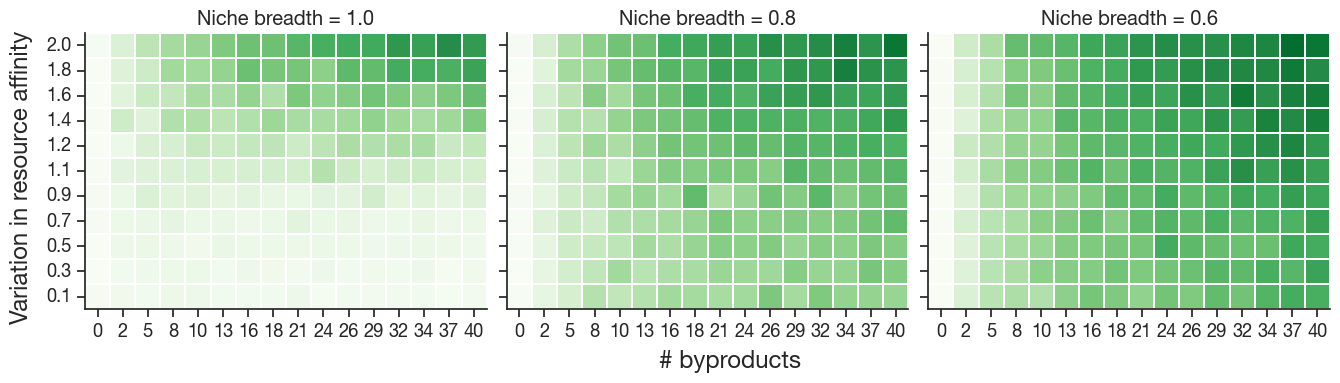

In [329]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(args.N_Csp):
    ax = axes[i]
    ax.set_title(f'Niche breadth = {1 - c_arr[i]:.1f}')
    # if i == args.N_Csp - 1:
    #     cbar = True
    # else:
    cbar = False
    sns.heatmap(richness_matrix[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = cbar,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='w', linewidths=0.1, annot=False, square=True)
    # )
fig.supylabel(r'Variation in resource affinity')
fig.supxlabel('# byproducts')
plt.subplots_adjust(left=0.07, wspace = 0.05, bottom = 0.15)
sns.despine(fig=fig, left=False, bottom=False)
# plt.title('Richness on single carbon source with 4 species community')
plt.savefig(figure_folder / '4_species_assembly_heatmap.pdf', dpi=300, bbox_inches='tight')

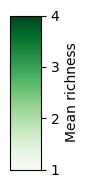

In [285]:
import matplotlib as mpl

# Set up normalization and colormap to match your heatmap
vmin, vmax = 1, 4
cmap = 'Greens'
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a new figure for just the colorbar
fig, ax = plt.subplots(figsize=(0.4, 2))
cbar = plt.colorbar(sm, cax=ax)
cbar.set_label('Mean richness')
plt.show()

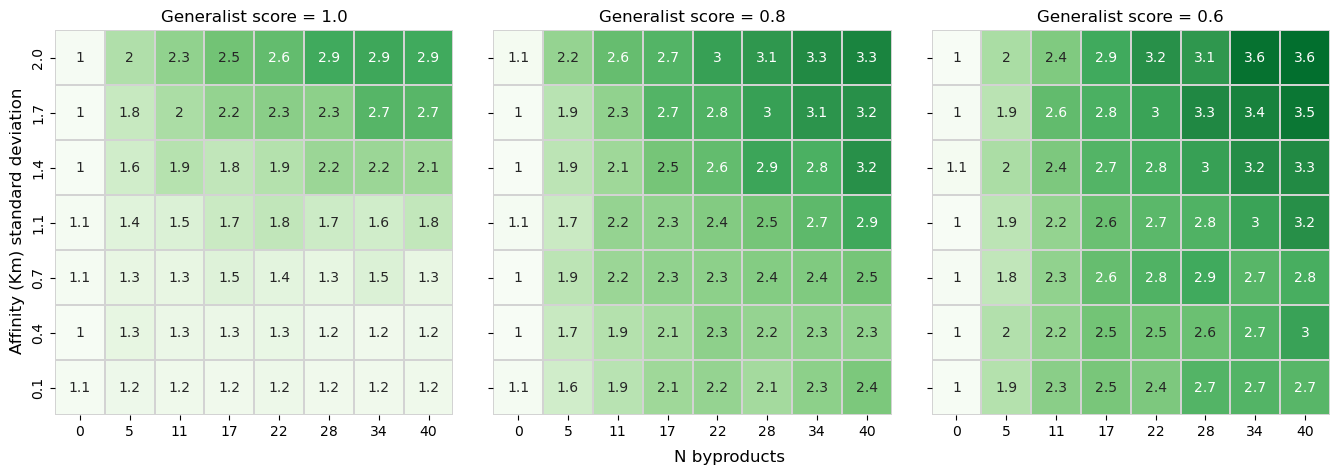

In [197]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
axes = axes.flatten()
for i,j in enumerate([0, 2, 4]):
    ax = axes[i]
    ax.set_title(f'Generalist score = {1 - c_arr[j]:.1f}')
    sns.heatmap(richness_matrix[:,::-1,j].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')
plt.savefig(figure_folder / f'20250826_richness_heatmap.pdf', bbox_inches='tight')

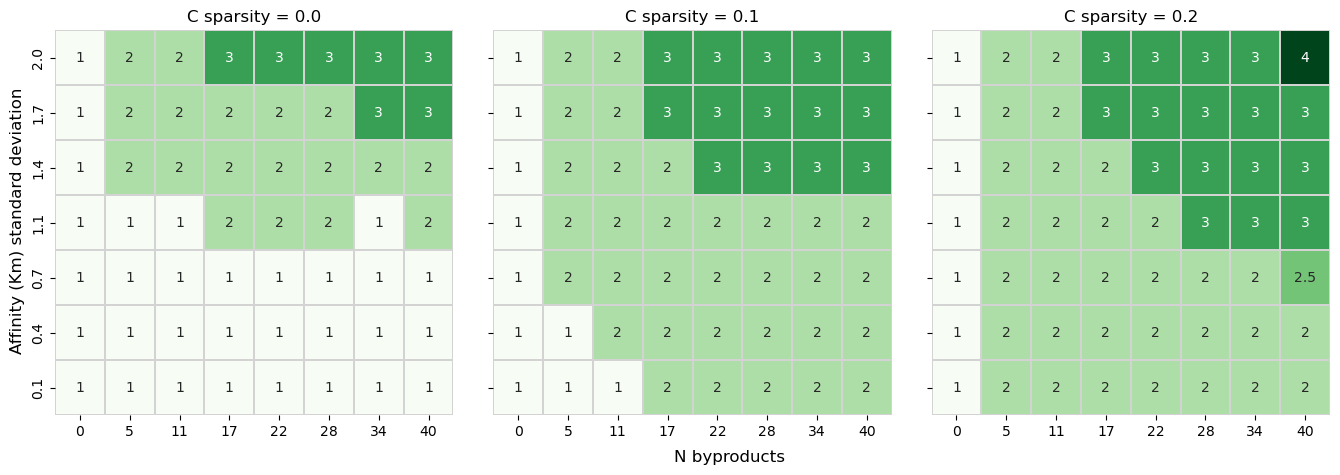

In [198]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for i in range(3):
    ax = axes[i]
    ax.set_title(f'C sparsity = {c_arr[i]:.1f}')
    sns.heatmap(median_richness[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')

Text(20.72222222222222, 0.5, 'C sparsity')

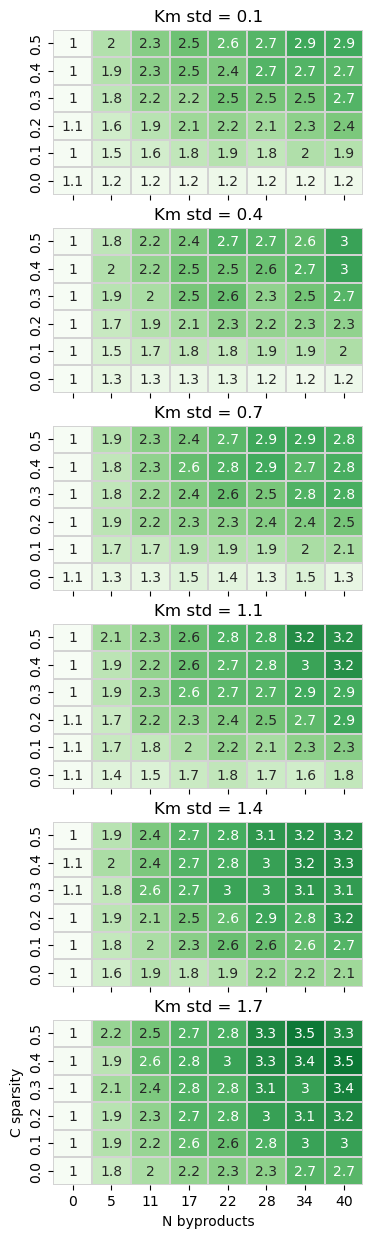

In [200]:
fig, axes = plt.subplots(6, 1, figsize=(4, 15), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(6):
    ax = axes[i]
    ax.set_title(f'Km std = {K_std_arr[i]:.1f}')
    sns.heatmap(richness_matrix[:,i,::-1].T, 
                yticklabels=[f'{x:.1f}' for x in c_arr][::-1],
                cmap='Greens',
                cbar = False,
                # cbar_kws={'label':'Mean richness'}, 
                # xticklabels = np.linspace(2, 30, 29, dtype=int)-1,
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
    plt.xlabel('N byproducts')
plt.ylabel('C sparsity')

# plt.title('Richness on single carbon source with 4 species community')

# Plot distributions

In [201]:
# Flatten the abundance matrix
flat = final_abundance_matrix.reshape(
    len(n_cs_arr) * len(K_std_arr) * len(c_arr) * final_abundance_matrix.shape[3], 
    final_abundance_matrix.shape[4]
)

# Create metadata for each row
metadata = []
for i, ncs in enumerate(n_cs_arr):
    for j, kstd in enumerate(K_std_arr):
        for k, csp in enumerate(c_arr):
            for l in range(final_abundance_matrix.shape[3]):  # iterations
                metadata.append((ncs, kstd, csp, l))

# Build DataFrame
abundance_df = pd.DataFrame(flat, columns=[f"species_{i+1}" for i in range(final_abundance_matrix.shape[4])])
abundance_df[['n_cs', 'K_std', 'c_sparsity', 'iteration']] = pd.DataFrame(metadata)

# Optional: set metadata as index
abundance_df.set_index(['n_cs', 'K_std', 'c_sparsity', 'iteration'], inplace=True)
abundance_df.reset_index(inplace=True)

In [202]:
abundance_df['Richness'] = (abundance_df[['species_1', 'species_2', 'species_3', 'species_4']] > 1e-6).sum(axis=1)

In [203]:
(abundance_df['Richness']==0).sum()

np.int64(24)

(0.0, 4.0)

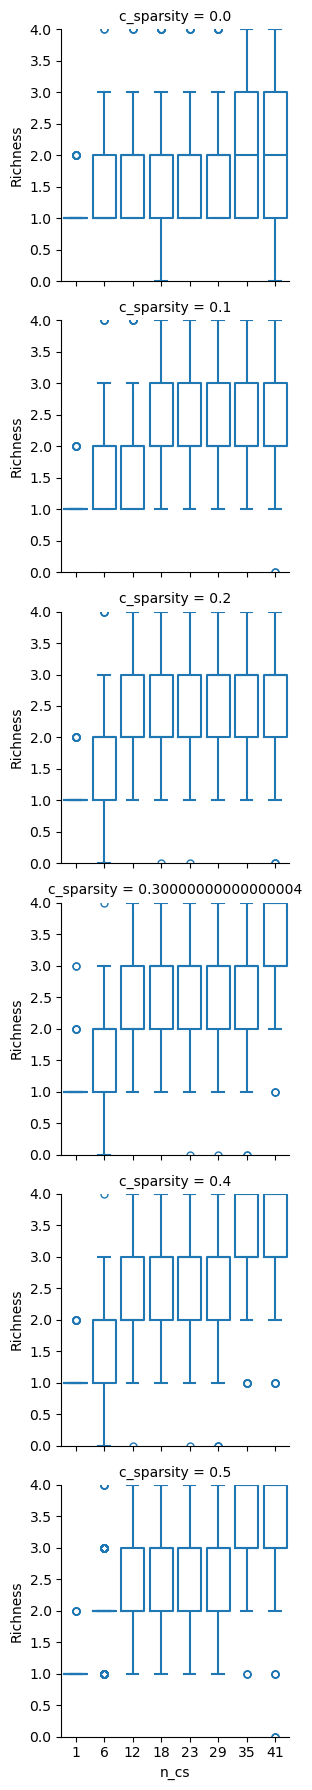

In [204]:

sns.catplot(data = abundance_df, 
            x = 'n_cs', y = 'Richness', 
            # col = 'K_std', 
            row = 'c_sparsity',
            kind = 'box',
            fill = False,
            # inner = None,
            height = 3, aspect = 1,
            sharey = True,
            sharex = True,
            # cut = 0
            )
plt.ylim(0, 4)

(0.0, 4.0)

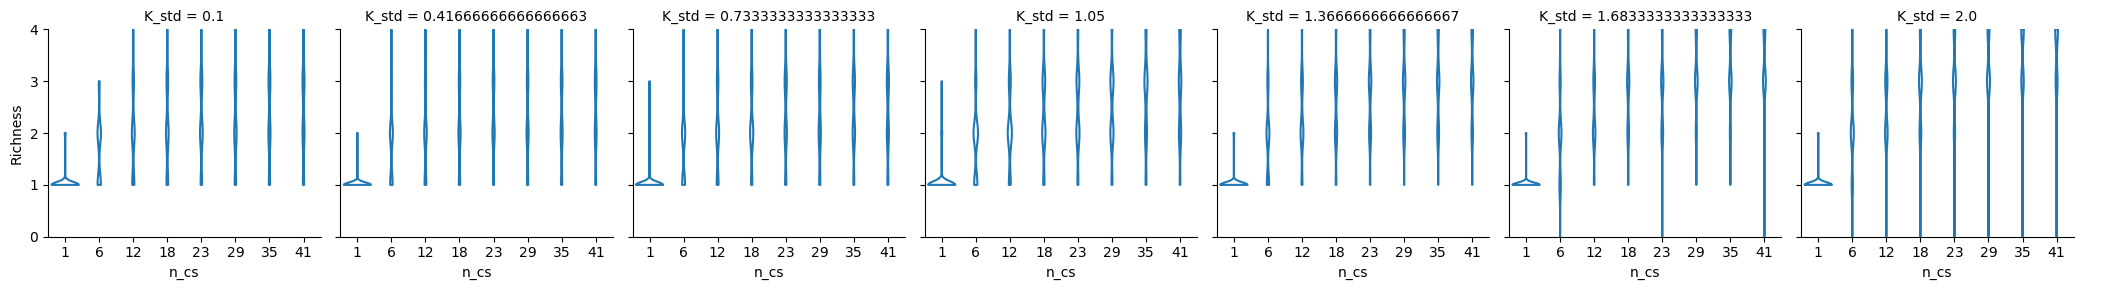

In [205]:

sns.catplot(data = abundance_df, 
            x = 'n_cs', y = 'Richness', 
            col = 'K_std', 
            # row = 'c_sparsity',
            kind = 'violin',
            fill = False,
            inner = None,
            height = 3, aspect = 1,
            sharey = True,
            sharex = True,
            cut = 0
            )
plt.ylim(0, 4)